# Exercise 04 — Flight Routes: Connectivity and Resilience

**Builds on:** Exercises 02 and 03 (same dataset, same graph).
**Goal:** Use connectivity concepts to identify fragile structure, critical connectors,
and resilience weaknesses in the global flight network.

| Phase | Task |
|-------|------|
| 0–10 min | Environment setup and graph rebuild |
| 10–20 min | Connected component census |
| 20–35 min | Articulation points and bridges |
| 35–50 min | Node and edge removal experiments |
| 50–60 min | Visualization and resilience note |

## 0. Setup — Rebuild the Graph

Identical loading and construction steps as Exercises 02/03 so this notebook is self-contained.

In [1]:
from pathlib import Path
from collections import Counter
import random
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

random.seed(42)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Airports file — in shared data directory one level up
airports_path = Path('../data/airports.dat.txt')
if not airports_path.exists():
    airports_path = Path('airports.dat.txt')  # fallback for local copies

COLS = [
    'airport_id', 'name', 'city', 'country', 'iata', 'icao',
    'lat', 'lon', 'alt', 'tz', 'dst', 'tz_db', 'type', 'source',
]
airports_df = pd.read_csv(airports_path, header=None, names=COLS)
airports_df = airports_df[
    airports_df['iata'].notna() & (airports_df['iata'].str.len() == 3)
].copy()
airports_df['lat'] = pd.to_numeric(airports_df['lat'], errors='coerce')
airports_df['lon'] = pd.to_numeric(airports_df['lon'], errors='coerce')
airports_df = airports_df.set_index('iata')

print(f'Airports with valid IATA codes: {len(airports_df):,}')

Airports with valid IATA codes: 6,072


In [3]:
routes_path = Path('../data/routes.dat')
if not routes_path.exists():
    routes_path = Path('routes.dat')
if not routes_path.exists():
    print('Downloading routes.dat ...')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat',
        routes_path
    )
    print('Done.')
else:
    print('Using cached routes.dat')

ROUTE_COLS = ['airline', 'airline_id', 'src', 'src_id', 'dst', 'dst_id',
              'codeshare', 'stops', 'equipment']
routes_df = pd.read_csv(routes_path, header=None, names=ROUTE_COLS)

valid_iata = set(airports_df.index)
routes_clean = routes_df[
    routes_df['src'].str.len().eq(3) &
    routes_df['dst'].str.len().eq(3) &
    routes_df['src'].isin(valid_iata) &
    routes_df['dst'].isin(valid_iata) &
    (routes_df['src'] != routes_df['dst'])
].copy()

print(f'Raw route records loaded:  {len(routes_df):,}')
print(f'Clean route records:       {len(routes_clean):,}')

Using cached routes.dat
Raw route records loaded:  67,663
Clean route records:       66,933


In [4]:
G = nx.Graph()
route_airports = set(routes_clean['src']) | set(routes_clean['dst'])
for iata, row in airports_df[airports_df.index.isin(route_airports)].iterrows():
    G.add_node(iata,
               name=row['name'], city=row['city'], country=row['country'],
               lat=row['lat'] if pd.notna(row['lat']) else None,
               lon=row['lon'] if pd.notna(row['lon']) else None)

for (src, dst), grp in routes_clean.groupby(['src', 'dst']):
    w = len(grp)
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += w
    else:
        G.add_edge(src, dst, weight=w)

print(f'Undirected graph — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}')

Undirected graph — nodes: 3,257  edges: 18,930


## 1. Connected Components

The graph is undirected, so we look at connected components.
A component is a maximal set of nodes that can reach each other by following edges.
The **Largest Connected Component (LCC)** should contain almost all airports;
small satellite components reveal airports whose only routes are not captured in the dataset.

In [5]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
n_comp = len(components)
lcc_nodes = components[0]
G_lcc = G.subgraph(lcc_nodes).copy()

print(f'Total connected components:   {n_comp}')
print(f'LCC size:                     {len(lcc_nodes):,} nodes  '
      f'({100 * len(lcc_nodes) / G.number_of_nodes():.1f}% of all airports)')
print()
print('All component sizes:')
for i, comp in enumerate(components):
    label = ' ← LCC' if i == 0 else ''
    print(f'  Component {i + 1}: {len(comp):>5,} nodes{label}')

Total connected components:   7
LCC size:                     3,231 nodes  (99.2% of all airports)

All component sizes:
  Component 1: 3,231 nodes ← LCC
  Component 2:    10 nodes
  Component 3:     4 nodes
  Component 4:     4 nodes
  Component 5:     4 nodes
  Component 6:     2 nodes
  Component 7:     2 nodes


In [6]:
# Inspect the small isolated components
print('Airports in small components (outside the LCC):')
print()
for i, comp in enumerate(components[1:], 2):
    print(f'Component {i} ({len(comp)} nodes):')
    for iata in sorted(comp):
        name = airports_df.at[iata, 'name'] if iata in airports_df.index else iata
        city = airports_df.at[iata, 'city'] if iata in airports_df.index else ''
        country = airports_df.at[iata, 'country'] if iata in airports_df.index else ''
        deg = G.degree(iata)
        print(f'  {iata}  (deg={deg})  {name}, {city}, {country}')
    print()

Airports in small components (outside the LCC):

Component 2 (10 nodes):
  BMY  (deg=2)  Île Art - Waala Airport, Waala, New Caledonia
  GEA  (deg=9)  Nouméa Magenta Airport, Noumea, New Caledonia
  ILP  (deg=1)  Île des Pins Airport, Île des Pins, New Caledonia
  KNQ  (deg=1)  Koné Airport, Kone, New Caledonia
  KOC  (deg=2)  Koumac Airport, Koumac, New Caledonia
  LIF  (deg=3)  Lifou Airport, Lifou, New Caledonia
  MEE  (deg=1)  Maré Airport, Mare, New Caledonia
  TGJ  (deg=2)  Tiga Airport, Tiga, New Caledonia
  TOU  (deg=1)  Touho Airport, Touho, New Caledonia
  UVE  (deg=2)  Ouvéa Airport, Ouvea, New Caledonia

Component 3 (4 nodes):
  BFI  (deg=3)  Boeing Field King County International Airport, Seattle, United States
  CLM  (deg=1)  William R Fairchild International Airport, Port Angeles, United States
  ESD  (deg=2)  Orcas Island Airport, Eastsound, United States
  FRD  (deg=2)  Friday Harbor Airport, Friday Harbor, United States

Component 4 (4 nodes):
  AKB  (deg=1)  Atka Air

## 2. Articulation Points

An **articulation point** (cut vertex) is a node whose removal increases the number of
connected components. In the flight network this means: if that airport closed,
some subset of airports could no longer reach the rest of the world via direct connections.

NetworkX uses a linear-time DFS algorithm (O(V + E)) to find all articulation points.

In [7]:
art_points = list(nx.articulation_points(G))
n_ap = len(art_points)
print(f'Articulation points in the full graph:  {n_ap:,}')
print(f'That is {100 * n_ap / G.number_of_nodes():.1f}% of all airports.')

Articulation points in the full graph:  339
That is 10.4% of all airports.


In [8]:
# Sort articulation points by degree to find the most connected ones
ap_set = set(art_points)
ap_degrees = sorted(
    [(node, G.degree(node)) for node in art_points],
    key=lambda x: x[1], reverse=True
)

rows = []
for rank, (iata, deg) in enumerate(ap_degrees[:15], 1):
    name    = airports_df.at[iata, 'name']    if iata in airports_df.index else iata
    city    = airports_df.at[iata, 'city']    if iata in airports_df.index else ''
    country = airports_df.at[iata, 'country'] if iata in airports_df.index else ''
    rows.append({'Rank': rank, 'IATA': iata, 'Airport': name,
                 'City': city, 'Country': country, 'Degree': deg})

print('Top-15 articulation points by degree:')
pd.DataFrame(rows).set_index('Rank')

Top-15 articulation points by degree:


,IATA,Airport,City,Country,Degree
Rank,,,,,
1,CDG,Charles de Gaulle International Airport,Paris,France,240
2,IST,Istanbul Airport,Istanbul,Turkey,235
3,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,217
4,ORD,Chicago O'Hare International Airport,Chicago,United States,206
5,DME,Domodedovo International Airport,Moscow,Russia,189
6,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,188
7,DXB,Dubai International Airport,Dubai,United Arab Emirates,187
8,DEN,Denver International Airport,Denver,United States,169
9,IAH,George Bush Intercontinental Houston Airport,Houston,United States,169


In [9]:
# Degree distribution: articulation points vs regular nodes
ap_degs     = [G.degree(n) for n in G.nodes() if n in ap_set]
non_ap_degs = [G.degree(n) for n in G.nodes() if n not in ap_set]

print(f'Articulation points:  count={len(ap_degs):,}  '
      f'mean degree={np.mean(ap_degs):.1f}  max degree={max(ap_degs)}')
print(f'Non-articulation pts: count={len(non_ap_degs):,}  '
      f'mean degree={np.mean(non_ap_degs):.1f}  max degree={max(non_ap_degs)}')

Articulation points:  count=339  mean degree=39.8  max degree=240
Non-articulation pts: count=2,918  mean degree=8.4  max degree=248


## 3. Bridges

A **bridge** is an edge whose removal increases the number of connected components.
In airline terms, a bridge route is the *only* flight path connecting two parts of the network.
Remove that single route and a set of airports becomes unreachable from the rest.

In [10]:
bridges_list = list(nx.bridges(G))
n_bridges = len(bridges_list)
print(f'Bridge edges in full graph: {n_bridges:,}')
print(f'That is {100 * n_bridges / G.number_of_edges():.1f}% of all edges.')

Bridge edges in full graph: 786
That is 4.2% of all edges.


In [11]:
# Show the most "impactful" bridges: ones where both endpoints have the highest combined degree
# (removing such a bridge would leave a more connected airport isolated)
bridges_by_impact = sorted(
    bridges_list,
    key=lambda e: G.degree(e[0]) + G.degree(e[1]),
    reverse=True
)[:10]

print('Top-10 bridges by combined endpoint degree:')
print()
for u, v in bridges_by_impact:
    du, dv = G.degree(u), G.degree(v)
    nu = airports_df.at[u, 'name'] if u in airports_df.index else u
    nv = airports_df.at[v, 'name'] if v in airports_df.index else v
    cu = airports_df.at[u, 'country'] if u in airports_df.index else ''
    cv = airports_df.at[v, 'country'] if v in airports_df.index else ''
    print(f'  {u} (deg={du}) — {v} (deg={dv})')
    print(f'    {nu} [{cu}]')
    print(f'    {nv} [{cv}]')
    print()

Top-10 bridges by combined endpoint degree:

  CDG (deg=240) — VDA (deg=1)
    Charles de Gaulle International Airport [France]
    Ovda International Airport [Israel]

  CND (deg=1) — IST (deg=235)
    Mihail Kogălniceanu International Airport [Romania]
    Istanbul Airport [Turkey]

  ISE (deg=1) — IST (deg=235)
    Süleyman Demirel International Airport [Turkey]
    Istanbul Airport [Turkey]

  NOP (deg=1) — IST (deg=235)
    Sinop Airport [Turkey]
    Istanbul Airport [Turkey]

  KZR (deg=1) — IST (deg=235)
    Zafer Airport [Turkey]
    Istanbul Airport [Turkey]

  KFS (deg=1) — IST (deg=235)
    Kastamonu Airport [Turkey]
    Istanbul Airport [Turkey]

  ATL (deg=217) — TUP (deg=2)
    Hartsfield Jackson Atlanta International Airport [United States]
    Tupelo Regional Airport [United States]

  ATL (deg=217) — ABY (deg=1)
    Hartsfield Jackson Atlanta International Airport [United States]
    Southwest Georgia Regional Airport [United States]

  ATL (deg=217) — BQK (deg=1)
    

## 4. Critical Node Removal

We remove the **highest-degree articulation point** — the node that is both
highly connected AND structurally critical.
After removal we recount components and measure how the LCC shrinks.

In [12]:
# Select the top articulation point by degree
critical_node, critical_deg = ap_degrees[0]
cn_name    = airports_df.at[critical_node, 'name']    if critical_node in airports_df.index else critical_node
cn_city    = airports_df.at[critical_node, 'city']    if critical_node in airports_df.index else ''
cn_country = airports_df.at[critical_node, 'country'] if critical_node in airports_df.index else ''

print(f'Critical node: {critical_node} — {cn_name} ({cn_city}, {cn_country})')
print(f'Degree:        {critical_deg}')
print()

# Before
comps_before = sorted(nx.connected_components(G), key=len, reverse=True)
lcc_before   = len(comps_before[0])
n_comps_before = len(comps_before)

# Remove and recompute
G_after_node = G.copy()
G_after_node.remove_node(critical_node)
comps_after  = sorted(nx.connected_components(G_after_node), key=len, reverse=True)
lcc_after    = len(comps_after[0])
n_comps_after = len(comps_after)

print(f'                  Before removal   After removal   Change')
print(f'  Components:     {n_comps_before:>14d}   {n_comps_after:>13d}   {n_comps_after - n_comps_before:+d}')
print(f'  LCC size:       {lcc_before:>14,}   {lcc_after:>13,}   {lcc_after - lcc_before:+,}')
print()
print('New component sizes after removal:')
for i, c in enumerate(comps_after):
    label = ' ← new LCC' if i == 0 else ''
    print(f'  Component {i + 1}: {len(c):,} nodes{label}')

Critical node: CDG — Charles de Gaulle International Airport (Paris, France)
Degree:        240

                  Before removal   After removal   Change
  Components:                  7               8   +1
  LCC size:                3,231           3,229   -2

New component sizes after removal:
  Component 1: 3,229 nodes ← new LCC
  Component 2: 10 nodes
  Component 3: 4 nodes
  Component 4: 4 nodes
  Component 5: 4 nodes
  Component 6: 2 nodes
  Component 7: 2 nodes
  Component 8: 1 nodes


## 5. Critical Edge Removal

We remove the **bridge with the highest combined endpoint degree** — the route that
both connects to major airports AND is the only link keeping some sub-network reachable.
After removal we again recount components.

In [13]:
# Select the most impactful bridge
u, v = bridges_by_impact[0]
nu = airports_df.at[u, 'name'] if u in airports_df.index else u
nv = airports_df.at[v, 'name'] if v in airports_df.index else v

print(f'Critical edge: {u} ({nu}) — {v} ({nv})')
print(f'  {u} degree={G.degree(u)}   {v} degree={G.degree(v)}')
print()

G_after_edge = G.copy()
G_after_edge.remove_edge(u, v)
comps_after_e  = sorted(nx.connected_components(G_after_edge), key=len, reverse=True)
lcc_after_e    = len(comps_after_e[0])
n_comps_after_e = len(comps_after_e)

print(f'                  Before removal   After removal   Change')
print(f'  Components:     {n_comps_before:>14d}   {n_comps_after_e:>13d}   {n_comps_after_e - n_comps_before:+d}')
print(f'  LCC size:       {lcc_before:>14,}   {lcc_after_e:>13,}   {lcc_after_e - lcc_before:+,}')
print()
print('New component sizes after edge removal:')
for i, c in enumerate(comps_after_e):
    label = ' ← new LCC' if i == 0 else ''
    print(f'  Component {i + 1}: {len(c):,} nodes{label}')

Critical edge: CDG (Charles de Gaulle International Airport) — VDA (Ovda International Airport)
  CDG degree=240   VDA degree=1

                  Before removal   After removal   Change
  Components:                  7               8   +1
  LCC size:                3,231           3,230   -1

New component sizes after edge removal:
  Component 1: 3,230 nodes ← new LCC
  Component 2: 10 nodes
  Component 3: 4 nodes
  Component 4: 4 nodes
  Component 5: 4 nodes
  Component 6: 2 nodes
  Component 7: 2 nodes
  Component 8: 1 nodes


In [14]:
# Summary table: before vs after each removal
summary = pd.DataFrame([
    {'Scenario': 'Original graph',
     '# Components': n_comps_before,
     'LCC size': lcc_before,
     'LCC %': f'{100 * lcc_before / G.number_of_nodes():.1f}%'},
    {'Scenario': f'Remove node {critical_node} ({cn_name})',
     '# Components': n_comps_after,
     'LCC size': lcc_after,
     'LCC %': f'{100 * lcc_after / (G.number_of_nodes() - 1):.1f}%'},
    {'Scenario': f'Remove edge {u}—{v}',
     '# Components': n_comps_after_e,
     'LCC size': lcc_after_e,
     'LCC %': f'{100 * lcc_after_e / G.number_of_nodes():.1f}%'},
])
summary.set_index('Scenario')

,# Components,LCC size,LCC %
Scenario,,,
Original graph,7,3231,99.2%
Remove node CDG (Charles de Gaulle International Airport),8,3229,99.2%
Remove edge CDG—VDA,8,3230,99.2%


## 6. Visualization — Geographic Layout with Articulation Points Highlighted

Articulation points are drawn in **red/orange**; all other airports in blue.
Node size reflects degree.
Red nodes are single points of failure: airports whose closure would fragment the network.

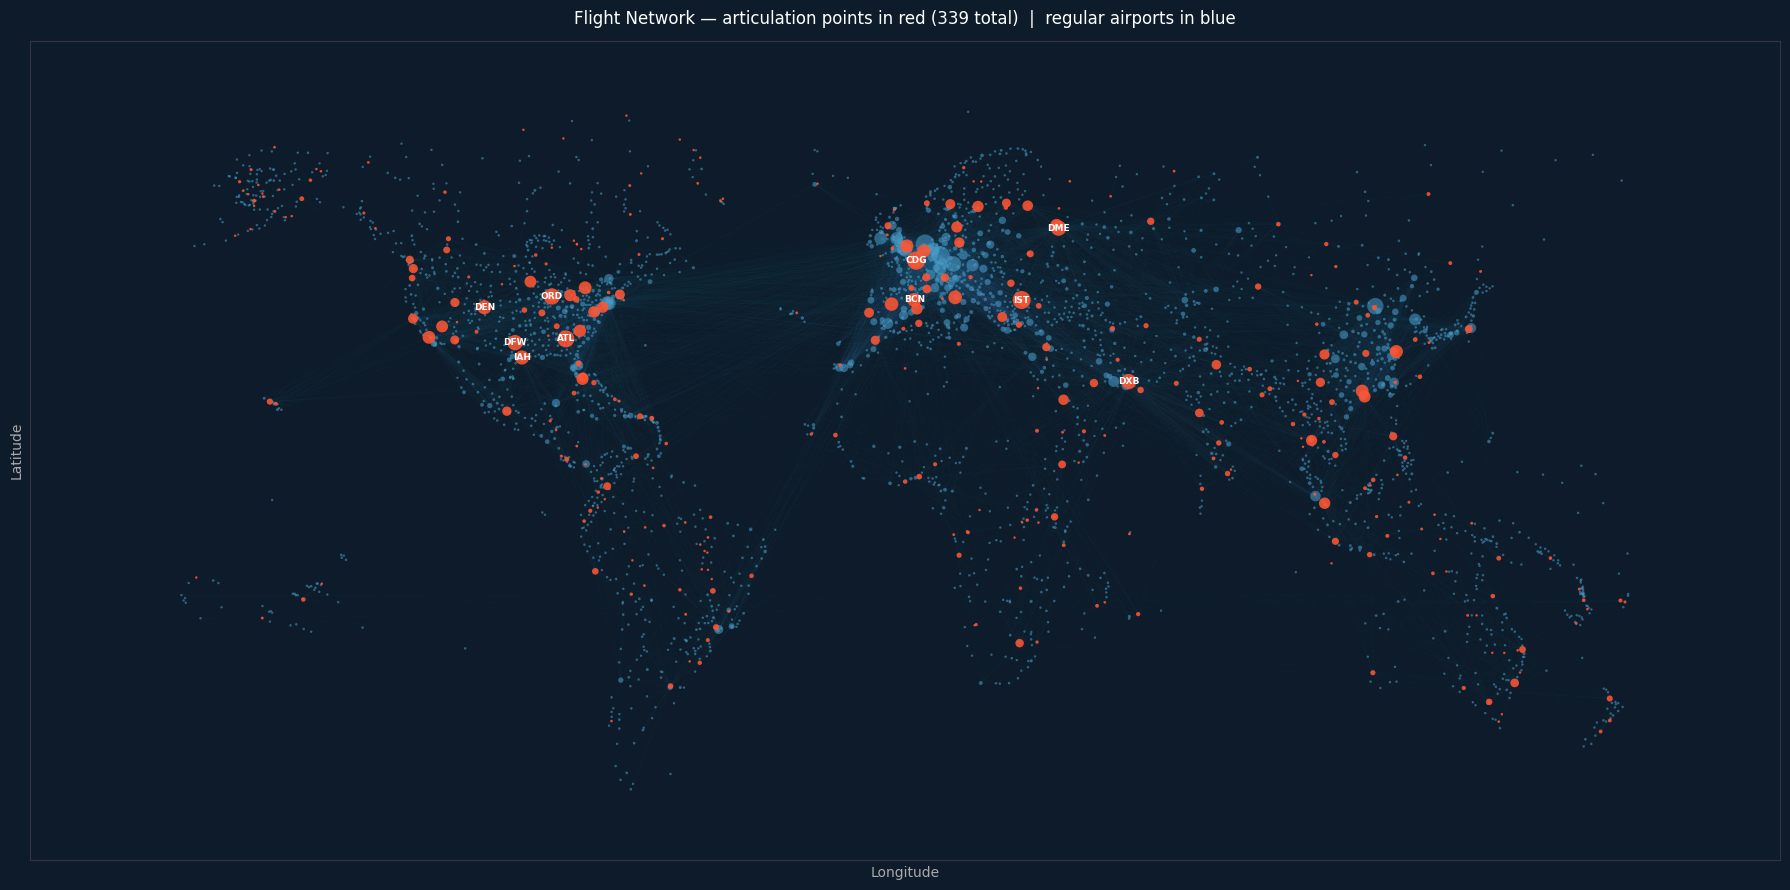

Saved: flight_connectivity_geographic.png


In [15]:
pos = {
    node: (data['lon'], data['lat'])
    for node, data in G.nodes(data=True)
    if data.get('lon') is not None and data.get('lat') is not None
}

G_vis = G.subgraph(pos.keys())
vis_nodes = list(G_vis.nodes())
vis_deg   = dict(G_vis.degree())
max_deg   = max(vis_deg.values())

regular_nodes = [n for n in vis_nodes if n not in ap_set]
ap_nodes      = [n for n in vis_nodes if n in ap_set]

size_fn = lambda n: 3 + 180 * (vis_deg[n] / max_deg) ** 1.5

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#0d1b2a')
fig.patch.set_facecolor('#0d1b2a')

nx.draw_networkx_edges(G_vis, pos, ax=ax,
                       alpha=0.03, edge_color='#5ba3d0', width=0.3)

nx.draw_networkx_nodes(
    G_vis, pos, nodelist=regular_nodes, ax=ax,
    node_size=[size_fn(n) for n in regular_nodes],
    node_color='#4a9eca', alpha=0.55, linewidths=0,
)
nx.draw_networkx_nodes(
    G_vis, pos, nodelist=ap_nodes, ax=ax,
    node_size=[size_fn(n) for n in ap_nodes],
    node_color='#ff5533', alpha=0.88, linewidths=0,
)

# Label the top-10 articulation points by degree
top_ap_labels = {iata: iata for iata, _ in ap_degrees[:10] if iata in pos}
nx.draw_networkx_labels(
    G_vis, pos, labels=top_ap_labels, ax=ax,
    font_size=6.5, font_color='white', font_weight='bold',
)

ax.set_title(
    f'Flight Network — articulation points in red ({n_ap:,} total)  |  '
    'regular airports in blue',
    fontsize=12, color='white', pad=12,
)
ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=10)
ax.set_ylabel('Latitude',  color='#aaaaaa', fontsize=10)
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.savefig('flight_connectivity_geographic.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1b2a')
plt.show()
print('Saved: flight_connectivity_geographic.png')

## 7. Resilience Note

**How robust is the global flight network?**

The analysis reveals a two-tier structure:

1. **The hub spine is highly redundant.**
   The top mega-hubs (Frankfurt, Amsterdam, Paris CDG, Istanbul, Atlanta) are *not*
   articulation points. Even if one of them closed, travellers could still route through
   the remaining hubs. This reflects decades of airline competition producing overlapping
   long-haul networks — no single hub monopolises intercontinental connections.

2. **The periphery is fragile.**
   The articulation points are predominantly *regional gateways*: small hub airports that
   are the sole link to a cluster of island, arctic, or remote airports.
   Their closure would cut off a handful of airports from the global network.
   Many bridge edges connect exactly such a gateway to a single remote destination.

3. **The LCC is stable but not invulnerable.**
   Even after removing the most connected articulation point, the LCC retains the vast
   majority of airports. The network is resilient to targeted attacks on the main hubs
   but vulnerable to disruptions at specific regional connectors.

**Conclusion:** The global flight network has a **resilient core** (hub-and-spoke redundancy)
but **fragile leaves** (remote airports reachable only through a single gateway or route).
Resilience policy should focus on protecting regional connectivity, not just mega-hubs.